In [1]:
import sys
sys.path.append('../cmldask')
import os, pickle, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from statsmodels.stats.multitest import multipletests
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed
import gc
import itertools

from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
import cmlreaders as cml
from compute_scalp_features import create_baseline_events

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option('display.max_columns', None)

In [2]:
EXP = 'CourierReinstate1'
# SUBJECTS = ['LTP564', 'LTP565']
SUBJECTS = ['LTP564', 'LTP565', 'LTP566', 'LTP567', 'LTP568', 'LTP569', 'LTP571', 'LTP572', 'LTP573',
            'LTP574', 'LTP575', 'LTP576', 'LTP577', 'LTP578', 'LTP579', 'LTP580', 'LTP581', 'LTP583',
            'LTP584', 'LTP585', 'LTP586', 'LTP587', 'LTP588', 'LTP589', 'LTP590', 'LTP591', 'LTP592', 
            'LTP593', 'LTP594', 'LTP595', 'LTP596', 'LTP597', 'LTP598', 'LTP599', 'LTP600', 'LTP601', 
            'LTP602', 'LTP603', 'LTP604', 'LTP605']

RETR_REL_START = -900
RETR_REL_STOP  =  -50
DELIB_REL_START = -900
DELIB_REL_STOP  = -50
BUFFER_MS_DELIB = 833.333333333

WIDTH = 6 
FREQS = np.logspace(np.log10(3), np.log10(128), 8)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
ROI_ORDER = ['LAI','RAI','LAS','RAS','LPS','RPS','LPI','RPI']

In [3]:
def assign_roi(channel):
    roi_dict = {
        'LAS':['C24','C25','D2','D3','D4','D11','D12','D13'],
        'LAI':['C31','C32','D5','D6','D9','D10','D21','D22'],
        'LPS':['D29','A5','A6','A7','A8','A17','A18'],
        'LPI':['D30','D31','A9','A10','A11','A15','A16'],
        'RAS':['B30','B31','B32','C2','C3','C4','C11','C12'],
        'RAI':['B24','B25','B28','B29','C5','C6','C9','C10'],
        'RPS':['A30','A31','A32','B3','B4','B5','B13'],
        'RPI':['A28','A29','B6','B7','B8','B11','B12'],
    }
    for roi, chans in roi_dict.items():
        if channel in chans:
            return roi
    return None

In [4]:
df_idx = cml.get_data_index('ltp').query("experiment == @EXP").copy()
if SUBJECTS is not None:
    df_idx = df_idx[df_idx['subject'].isin(SUBJECTS)]
subjects = sorted(df_idx.subject.unique())
print(f'Found {len(subjects)} subjects for experiment "{EXP}".')

Found 40 subjects for experiment "CourierReinstate1".


In [5]:
def welch_t_from_agg(n1, sum1, sumsq1, n0, sum0, sumsq0):
    """
    All arrays are shape (n_channels, n_freqs) or scalars broadcastable thereto.
    Returns t of shape (n_channels, n_freqs).
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        m1 = sum1 / np.maximum(n1, 1)
        m0 = sum0 / np.maximum(n0, 1)
        v1 = (sumsq1 - (sum1**2)/np.maximum(n1, 1)) / np.maximum(n1 - 1, 1)
        v0 = (sumsq0 - (sum0**2)/np.maximum(n0, 1)) / np.maximum(n0 - 1, 1)
        denom = np.sqrt(v1 / np.maximum(n1, 1) + v0 / np.maximum(n0, 1))
        t = (m1 - m0) / denom
        t[~np.isfinite(t)] = np.nan
    return t

In [6]:
def ensure_trial_col(df):
    if 'trial' in df.columns:
        return df
    for alt in ['list', 'trialno', 'trial_num', 'trial_number']:
        if alt in df.columns:
            return df.rename(columns={alt: 'trial'})
    # Fallback: make a synthetic trial within session (should rarely be needed)
    g = df.groupby(['subject','session'], sort=False).cumcount()
    out = df.copy()
    out['trial'] = g
    return out

In [7]:
REQUIRED_NUMERIC = ['session', 'trial', 'mstime']
OPTIONAL_NUMERIC = ['intrusion', 'serialpos', 'repetition', 'itemno', 'list', 'eegoffset']
STRING_COLS      = ['type', 'eegfile', 'phase']

def prep_for_baseline(evs: pd.DataFrame) -> pd.DataFrame:
    e = evs.copy()

    # Ensure we have a 'trial' column with a sensible name
    if 'trial' not in e.columns:
        for alt in ['list','trialno','trial_num','trial_number']:
            if alt in e.columns:
                e = e.rename(columns={alt: 'trial'})
                break

    e = e.replace(r'^\s*$', np.nan, regex=True)
    
    # Coerce numeric columns; empty strings -> NaN
    for col in REQUIRED_NUMERIC + OPTIONAL_NUMERIC:
        if col in e.columns:
            e[col] = pd.to_numeric(e[col], errors='coerce')

    # If present, intrusion NaN -> 0 (non-intrusions)
    if 'intrusion' in e.columns:
        e['intrusion'] = e['intrusion'].fillna(0)

    # Ensure anchors exist and drop rows missing anchors
    if not set(REQUIRED_NUMERIC).issubset(e.columns):
        return e.iloc[0:0].copy()
    e = e.dropna(subset=REQUIRED_NUMERIC)
    
    # Cast anchors to int64
    for col in REQUIRED_NUMERIC:
        e[col] = e[col].astype(np.int64)

    # Ensure required string columns exist and are string dtype
    for col in STRING_COLS:
        if col not in e.columns:
            e[col] = ''
        else:
            e[col] = e[col].fillna('').astype(str)

    return e

def df_to_recarray_with_dtype(df: pd.DataFrame) -> np.recarray:
    """
    Build a structured recarray with explicit dtypes:
      - REQUIRED_NUMERIC & OPTIONALLY numeric columns: int64/float64
      - STRING_COLS ('type','eegfile','phase'): Unicode strings
      - others: use a conservative string fallback
    """
    names, formats, arrays = [], [], []

    for name in df.columns:
        if name in STRING_COLS:
            arr = df[name].fillna('').astype(str).to_numpy()
            fmt = 'U128'
        else:
            dt = df[name].dtype
            if np.issubdtype(dt, np.integer):
                arr = df[name].astype(np.int64).to_numpy()
                fmt = np.int64
            elif np.issubdtype(dt, np.floating):
                arr = df[name].astype(np.float64).to_numpy()
                fmt = np.float64
            else:
                # Fallback to string for anything non-numeric
                arr = df[name].fillna('').astype(str).to_numpy()
                fmt = 'U128'
        names.append(name); formats.append(fmt); arrays.append(arr)

    # Create recarray without FutureWarning (avoid fromrecords with list-of-lists)
    rec = np.rec.fromarrays(arrays, names=names, formats=formats)
    return rec

In [9]:
# =====TEST CELL=====

for s in SUBJECTS:
    df = sessions = cml.get_data_index('ltp').query("experiment == @EXP and subject == @s")
    df_sess = df.iloc[0]
    reader = cml.CMLReader(subject=df_sess['subject'], 
                           experiment=df_sess['experiment'], 
                           session=df_sess['session'])
    evs_all = reader.load('task_events')
evs_all

,eegoffset,classifier,correctPointingDirection,eegfile,efr_mark,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,montage,msoffset,mstime,phase,presX,presZ,protocol,recalled,rectime,serialpos,session,store,storeX,storeZ,subject,submittedPointingDirection,trial,type
0,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1727796102692,1,-999.000000,-999.000000,ltp,-999,-999,-999,1,-999,-999.000000,-999.000000,LTP564,-999,0,store mappings
1,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1727796156090,1,-999.000000,-999.000000,ltp,-999,-999,-999,1,-999,-999.000000,-999.000000,LTP564,-999,0,TRIAL_START
2,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,XYLOPHONE,-999,0,-1,1727796191008,1,-29.250000,46.781250,ltp,1,-999,1,1,clothing_store,-31.812500,55.718750,LTP564,-999,0,WORD
3,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,KNIFE,-999,0,-1,1727796214191,1,24.890625,1.380859,ltp,1,-999,2,1,pharmacy,26.484375,16.953125,LTP564,-999,0,WORD
4,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1727796226425,1,-0.592773,-34.375000,ltp,-999,-999,-999,1,-999,-999.000000,-999.000000,LTP564,-999,0,POINTER_ON
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1354,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,CHILIPEPPERS,-999,0,-1,1727802803207,2,-35.625000,-48.875000,ltp,0,-999,10,1,bike_shop,-38.937500,-61.875000,LTP564,-999,11,WORD
1355,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,TORCH,-999,0,-1,1727802811021,2,-9.156250,-47.156250,ltp,0,-999,-999,1,-999,-999.000000,-999.000000,LTP564,-999,11,REINSTATEMENT
1356,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,TORCH,-999,0,-1,1727802811188,2,-7.632812,-47.437500,ltp,0,-999,-999,1,-999,-999.000000,-999.000000,LTP564,-999,11,REINSTATEMENT
1357,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,TORCH,-999,0,-1,1727802811355,2,-6.101562,-47.656250,ltp,0,-999,-999,1,-999,-999.000000,-999.000000,LTP564,-999,11,REINSTATEMENT


In [10]:
# =====TEST CELL=====

has_phase = 'phase' in evs_all.columns
rec_mask = evs_all['type'].isin(['REC_START','REC_STOP','REC_WORD','REC_WORD_VV'])
if has_phase:
    rec_mask &= (evs_all['phase'] != 'practice')
rec_evs0 = evs_all.loc[rec_mask].reset_index(drop=True)
rec_evs0 = prep_for_baseline(rec_evs0)
rec_evs0

,eegoffset,classifier,correctPointingDirection,eegfile,efr_mark,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,montage,msoffset,mstime,phase,presX,presZ,protocol,recalled,rectime,serialpos,session,store,storeX,storeZ,subject,submittedPointingDirection,trial,type
0,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1727796702626,1,-5.890625,-46.8125,ltp,-999,-999,-999,1,-999,-999.000000,-999.000000,LTP564,-999,0,REC_START
1,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,0,XYLOPHONE,173,0,20,1727796705237,1,-5.890625,-46.8125,ltp,-999,2611,1,1,clothing_store,-31.812500,55.718750,LTP564,-999,0,REC_WORD
2,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,0,KNIFE,77,0,20,1727796706490,1,-5.890625,-46.8125,ltp,-999,3864,2,1,pharmacy,26.484375,16.953125,LTP564,-999,0,REC_WORD
3,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,0,WEIGHTS,171,0,20,1727796707504,1,-5.890625,-46.8125,ltp,-999,4878,3,1,barber_shop,36.750000,59.062500,LTP564,-999,0,REC_WORD
4,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,0,FISH,53,0,20,1727796708636,1,-5.890625,-46.8125,ltp,-999,6010,4,1,gym,-29.562500,-37.250000,LTP564,-999,0,REC_WORD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,9,KETTLE,75,0,20,1727802549343,2,13.820312,-48.4375,ltp,-999,20168,14,1,dentist,14.546875,-58.781250,LTP564,-999,10,REC_WORD
155,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,0,TEAPOT,150,0,20,1727802550664,2,13.820312,-48.4375,ltp,-999,21489,2,1,florist,-60.000000,-11.500000,LTP564,-999,10,REC_WORD
156,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,0,FORK,57,0,20,1727802551752,2,13.820312,-48.4375,ltp,-999,22577,3,1,pizzeria,59.281250,-9.156250,LTP564,-999,10,REC_WORD
157,-1,X,-999,,-999,-1,CourierReinstate1,-999,-999,0,MIXER,86,0,20,1727802552872,2,13.820312,-48.4375,ltp,-999,23697,4,1,grocery_store,-3.070312,-58.500000,LTP564,-999,10,REC_WORD


In [16]:
# =====TEST CELL=====

for s in SUBJECTS:
    process_subject_stats(s, EXP, BATCH_EVENTS)

[WARN] LTP564 session 1 skipped: split EEG filenames don't seem to match what are in the events
[WARN] LTP564 session 3 skipped: split EEG filenames don't seem to match what are in the events
Opening raw data file /protocols/ltp/subjects/LTP564/experiments/CourierReinstate1/sessions/4/ephys/current_processed/LTP564_session_4_clean_raw.fif...
    Range : 0 ... 4190207 =      0.000 ...  2046.000 secs
Ready.
Opening raw data file /protocols/ltp/subjects/LTP564/experiments/CourierReinstate1/sessions/4/ephys/current_processed/LTP564_session_4_clean_raw-1.fif...
    Range : 4190208 ... 8380415 =   2046.000 ...  4092.000 secs
Ready.
Opening raw data file /protocols/ltp/subjects/LTP564/experiments/CourierReinstate1/sessions/4/ephys/current_processed/LTP564_session_4_clean_raw-2.fif...
    Range : 8380416 ... 10885119 =   4092.000 ...  5315.000 secs
Ready.
Reading 0 ... 10885119  =      0.000 ...  5315.000 secs...
Not setting metadata
64 matching events found
No baseline correction applied
0 pr

In [8]:
def process_subject_stats(subject, EXP=EXP, batch=BATCH_EVENTS):
    """
    Returns DataFrame: subject, channel, frequency, t
    Group 1 (n1): Successful retrieval epochs (−900 to −50 ms relative to REC_WORD onset)
    Group 0 (n0): Matched deliberation epochs (−900 to −50 ms relative to REC_BASE, which is the end of the silent window)
    """

    sessions = cml.get_data_index('ltp').query(
        "experiment == @EXP and subject == @subject"
    ).session.unique()

    n1, n0 = {}, {}
    sum1, sum0 = {}, {}
    sumsq1, sumsq0 = {}, {}
    freq_vec = FREQS

    for sess in sessions:
        ret_evs = None
        delib_evs = None
        try:
            reader = cml.CMLReader(subject=subject, experiment=EXP, session=sess)
            evs_all = reader.load('task_events')
            if evs_all.empty:
                continue

            # ---------- recall-phase subset ----------
            has_phase = 'phase' in evs_all.columns
            rec_mask = evs_all['type'].isin(['REC_START','REC_STOP','REC_WORD','REC_WORD_VV'])
            if has_phase:
                rec_mask &= (evs_all['phase'] != 'practice')
            rec_evs0 = evs_all.loc[rec_mask].reset_index(drop=True)

            # ---------- guards ----------
            if rec_evs0.empty or (rec_evs0['type'].eq('REC_START').sum()==0) or (rec_evs0['type'].eq('REC_STOP').sum()==0):
                print(f"[{subject} s{sess}] no recall bounds -> skip")
                continue

            # ---------- clean anchors & string cols ----------
            rec_evs0 = prep_for_baseline(rec_evs0)
            if rec_evs0.empty or (rec_evs0['type'].eq('REC_WORD').sum() == 0):
                print(f"[{subject} s{sess}] cleaned table empty -> skip")
                continue

            # ---------- recarray with explicit dtypes ----------
            events_rec = df_to_recarray_with_dtype(rec_evs0)
            dt = events_rec.dtype
            assert dt['eegfile'].kind in ('U','S'), f"eegfile dtype must be string, got {dt['eegfile']}"
            assert dt['phase'].kind   in ('U','S'), f"phase dtype must be string, got {dt['phase']}"
            assert dt['type'].kind    in ('U','S'), f"type dtype must be string, got {dt['type']}"

            # ---------- build matched deliberation (REC_BASE) ----------
            from compute_scalp_features import create_baseline_events
            rec_evs = pd.DataFrame.from_records(
                create_baseline_events(events_rec, start_time=3000, end_time=90000)
            ).reset_index(drop=True)

            # keep only retrieval (REC_WORD) and matched deliberation (REC_BASE)
            pairs = rec_evs.query("type in ['REC_WORD','REC_BASE']").copy()
            if pairs.empty:
                print(f"[{subject} s{sess}] no REC_WORD/REC_BASE -> skip")
                continue

            # remove repetitions (first instance per (session, trial))
            if 'item' in pairs.columns:
                pairs = pairs.sort_values(['session','trial','mstime'])
                pairs['repetition'] = 0
                seen = {}
                for i, row in pairs.iterrows():
                    if row['type'] != 'REC_WORD':
                        continue
                    key = (row['session'], row['trial'])
                    if key not in seen:
                        seen[key] = set()
                    if row['item'] in seen[key]:
                        pairs.at[i, 'repetition'] = 1
                    else:
                        seen[key].add(row['item'])
                pairs = pairs.query("(type == 'REC_BASE') | (repetition == 0)").copy()
                pairs.drop(columns=['repetition'], inplace=True, errors='ignore')

            # drop intrusions (keep all REC_BASE)
            if 'intrusion' in pairs.columns:
                pairs = pairs.query("intrusion == 0 or type == 'REC_BASE'").copy()

            # basic hygiene
            if 'eegoffset' in pairs.columns:
                pairs = pairs[pairs['eegoffset'].fillna(0) >= 0].copy()
            if set(['eegfile','eegoffset']).issubset(pairs.columns):
                pairs = pairs.drop_duplicates(subset=['eegfile','eegoffset']).copy()

            # ---------- split into groups ----------
            ret_evs   = pairs[pairs['type'] == 'REC_WORD'].reset_index(drop=True)
            delib_evs = pairs[pairs['type'] == 'REC_BASE'].reset_index(drop=True)

            if ret_evs.empty and delib_evs.empty:
                print(f"[{subject} s{sess}] ret=0 delib=0 -> skip")
                continue

            # build the wavelet *once* so it's available to both branches
            mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output='power', complete=True)

            # -------- Process in batches (unchanged structure) --------
            for start in range(0, max(len(ret_evs), len(delib_evs)), batch):
                # We load each group independently in batches
                ret_batch   = ret_evs.iloc[start:start+batch]
                delib_batch = delib_evs.iloc[start:start+batch]

                # Retrieval: −900→−50 with mirrored buffer
                if not ret_batch.empty:
                    eeg_ret = reader.load_eeg(
                        ret_batch,
                        rel_start=RETR_REL_START - BUFFER_MS_DELIB,
                        rel_stop =RETR_REL_STOP  + BUFFER_MS_DELIB,
                        clean='LCF'
                    ).to_ptsa()
                    eeg_ret = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg_ret)
                    pwr_ret = mw.filter(eeg_ret).sel(time=slice(RETR_REL_START, RETR_REL_STOP)).mean(dim='time')
                    pret = pwr_ret.transpose('event', 'channel', 'frequency').values
                    chans = pwr_ret['channel'].values

                    # init accumulators for any new channels
                    for ci, ch in enumerate(chans):
                        if ch not in n1:
                            z = np.zeros(len(freq_vec), dtype=np.float64)
                            n1[ch] = 0; n0[ch] = 0
                            sum1[ch] = z.copy(); sum0[ch] = z.copy()
                            sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()
                    if pret.shape[0] > 0:
                        s  = pret.sum(axis=0); ss = (pret**2).sum(axis=0); cnt = pret.shape[0]
                        for ci, ch in enumerate(chans):
                            sum1[ch]   += s[ci]
                            sumsq1[ch] += ss[ci]
                            n1[ch]     += cnt
                    del eeg_ret, pwr_ret, pret

                # Deliberation: also −900→−50 relative to REC_BASE anchor
                if not delib_batch.empty:
                    eeg_del = reader.load_eeg(
                        delib_batch,
                        rel_start=DELIB_REL_START - BUFFER_MS_DELIB,
                        rel_stop =DELIB_REL_STOP  + BUFFER_MS_DELIB,
                        clean='LCF'
                    ).to_ptsa()
                    eeg_del = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg_del)
                    pwr_del = mw.filter(eeg_del).sel(time=slice(DELIB_REL_START, DELIB_REL_STOP)).mean(dim='time')
                    pdel = pwr_del.transpose('event', 'channel', 'frequency').values
                    chans = pwr_del['channel'].values  # same ordering as above

                    for ci, ch in enumerate(chans):
                        if ch not in n0:
                            z = np.zeros(len(freq_vec), dtype=np.float64)
                            n1[ch] = 0; n0[ch] = 0
                            sum1[ch] = z.copy(); sum0[ch] = z.copy()
                            sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()
                    if pdel.shape[0] > 0:
                        s  = pdel.sum(axis=0); ss = (pdel**2).sum(axis=0); cnt = pdel.shape[0]
                        for ci, ch in enumerate(chans):
                            sum0[ch]   += s[ci]
                            sumsq0[ch] += ss[ci]
                            n0[ch]     += cnt
                    del eeg_del, pwr_del, pdel

                gc.collect()

        except Exception as e:
            print(f"[WARN] {subject} session {sess} skipped: {e}")
            continue

    # ----- assemble channel×freq arrays and compute Welch t (unchanged) -----
    if not n1:
        return pd.DataFrame(columns=['subject','channel','frequency','t'])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i,:]  = n1[ch];   N0[i,:]  = n0[ch]
        S1[i,:]  = sum1[ch]; S0[i,:]  = sum0[ch]
        SS1[i,:] = sumsq1[ch]; SS0[i,:] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

    df = (pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=['channel','frequency']),
            columns=['t']
         ).reset_index())
    df['subject'] = subject
    return df

In [9]:
client = da.new_dask_client_slurm(
    job_name="retrieval",
    memory_per_job="50GB",
    max_n_jobs=10,
    queue="RAM",
    local_directory="",
    log_directory="dask_logs"
)

Unique port for joycerose14 is 51609
{'dashboard_address': ':51609'}
To view the dashboard, run: 
`ssh -fN joycerose14@rhino2.psych.upenn.edu -L 8000:192.168.86.106:51609` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


In [10]:
futures = [client.submit(process_subject_stats, s, EXP, BATCH_EVENTS) for s in subjects]

In [11]:
subj_chan_t_list, n_done, n_fail = [], 0, 0
for fut in as_completed(futures):
    try:
        df = fut.result()
        subj_chan_t_list.append(df)
        n_done += 1
        sub = df['subject'].iat[0] if not df.empty else 'EMPTY_SUBJECT'
        print(f"[DONE] {n_done}/{len(subjects)} :: {sub} (rows={len(df)})")
    except Exception as e:
        n_fail += 1
        print(f"[ERR] Future failed ({n_fail} fails): {e}")

[DONE] 1/40 :: LTP565 (rows=1024)
[DONE] 2/40 :: LTP569 (rows=1024)
[DONE] 3/40 :: LTP564 (rows=1024)
[DONE] 4/40 :: LTP578 (rows=1024)
[DONE] 5/40 :: LTP580 (rows=1024)
[DONE] 6/40 :: EMPTY_SUBJECT (rows=0)
[DONE] 7/40 :: LTP567 (rows=1024)
[DONE] 8/40 :: LTP583 (rows=1024)
[DONE] 9/40 :: LTP576 (rows=1024)
[DONE] 10/40 :: LTP572 (rows=1024)
[DONE] 11/40 :: LTP566 (rows=1024)
[DONE] 12/40 :: LTP577 (rows=1024)
[DONE] 13/40 :: LTP568 (rows=1024)
[DONE] 14/40 :: LTP574 (rows=1024)
[DONE] 15/40 :: LTP575 (rows=1024)
[DONE] 16/40 :: LTP584 (rows=1024)
[DONE] 17/40 :: LTP590 (rows=1024)
[DONE] 18/40 :: LTP581 (rows=1024)
[DONE] 19/40 :: LTP588 (rows=1024)
[DONE] 20/40 :: LTP592 (rows=1024)
[DONE] 21/40 :: LTP573 (rows=1024)
[DONE] 22/40 :: LTP571 (rows=1024)
[DONE] 23/40 :: LTP585 (rows=1024)
[DONE] 24/40 :: LTP587 (rows=1024)
[DONE] 25/40 :: LTP594 (rows=1024)
[DONE] 26/40 :: LTP593 (rows=1024)
[DONE] 27/40 :: LTP600 (rows=1024)
[DONE] 28/40 :: LTP586 (rows=1024)
[DONE] 29/40 :: LTP589 (r

In [13]:
client.shutdown()

In [14]:
chan_t_all = (pd.concat(subj_chan_t_list, ignore_index=True)
              if subj_chan_t_list else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
print("Combined channel×freq rows:", len(chan_t_all))

Combined channel×freq rows: 39936


In [15]:
chan_t_all['ROI'] = chan_t_all['channel'].map(assign_roi)
chan_t_all = chan_t_all.dropna(subset=['ROI']).copy()

subj_roi_t = (chan_t_all
              .groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [16]:
def one_samp(s):
    s = s.dropna()
    if s.empty: return pd.Series({'t_mean':np.nan,'p':np.nan})
    t_mean = s.mean()
    _, p = stats.ttest_1samp(s, 0.0, nan_policy='omit')
    return pd.Series({'t_mean':t_mean, 'p':p})

In [17]:
mean_tbl = (subj_roi_t
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long = (subj_roi_t
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg = mean_tbl.merge(p_tbl_long, on=['ROI','frequency'], how='outer')

heat = agg.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat.columns]
if cols_present:
    heat = heat[cols_present]

p_tbl = agg.pivot(index='frequency', columns='ROI', values='p')
if cols_present:
    p_tbl = p_tbl[cols_present]

rej, p_adj, *_ = multipletests(p_tbl.values.ravel(), method='fdr_bh')
p_adj_tbl = pd.DataFrame(p_adj.reshape(p_tbl.shape),
                         index=p_tbl.index, columns=p_tbl.columns)

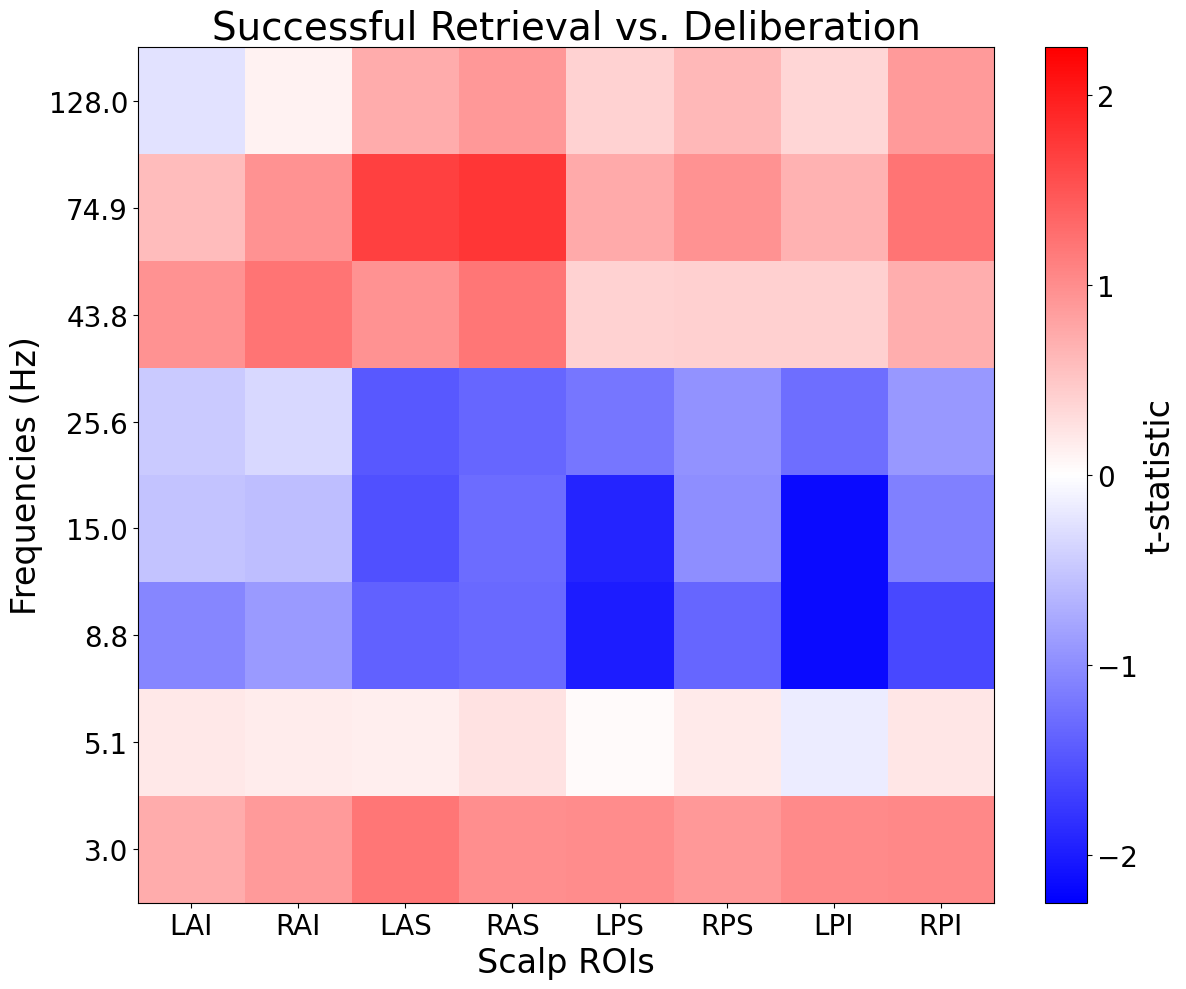

In [18]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat, cmap='bwr', aspect='auto', norm=norm)

freqs = heat.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(list(heat.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful Retrieval vs. Deliberation', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', fontsize=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)

# sig = (p_adj_tbl.loc[heat.index, heat.columns].values < 0.05)
# for (i, j), ok in np.ndenumerate(sig):
#     if ok:
#         ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, lw=1.5, edgecolor='k'))

plt.tight_layout()
plt.show()